# Importaçao de Blibliotecas

In [4]:
import os
import json
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de Reprodutibilidade e Ambiente

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEMENTE_GLOBAL = 42

random.seed(SEMENTE_GLOBAL)
np.random.seed(SEMENTE_GLOBAL)
os.environ['PYTHONHASHSEED'] = str(SEMENTE_GLOBAL)

torch.manual_seed(SEMENTE_GLOBAL)
torch.cuda.manual_seed(SEMENTE_GLOBAL)
torch.cuda.manual_seed_all(SEMENTE_GLOBAL)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Rodando na: {device}")
print(f"Sementes globais fixadas em {SEMENTE_GLOBAL} para reprodutibilidade.")

Rodando na: cuda
Sementes globais fixadas em 42 para reprodutibilidade.


# Pré-processamento das Imagens

In [13]:
def extrai_fft_da_imagem(imagem, tamanho_fft=512):
    """
    Calcula a magnitude da FFT bidimensional da imagem.

    A imagem é convertida para escala de cinza e redimensionada antes da
    transformada. O resultado é normalizado para o intervalo [0, 1].

    Args:
        imagem (PIL.Image): imagem de entrada.
        tamanho_fft (int): resolução usada no cálculo da FFT.

    Returns:
        np.ndarray: magnitude espectral normalizada.
    """
    imagem_cinza = imagem.convert("L")
    imagem_redimensionada = imagem_cinza.resize(
        (tamanho_fft, tamanho_fft),
        Image.Resampling.BILINEAR
    )

    matriz_cinza = np.array(imagem_redimensionada, dtype=np.float32) / 255.0

    fft = np.fft.fft2(matriz_cinza)
    fft_centralizada = np.fft.fftshift(fft)

    magnitude = np.log(np.abs(fft_centralizada) + 1e-8)

    minimo = magnitude.min()
    maximo = magnitude.max()

    if maximo - minimo > 1e-8:
        magnitude = (magnitude - minimo) / (maximo - minimo)
    else:
        magnitude = np.zeros_like(magnitude, dtype=np.float32)

    return magnitude

def obter_transformacao_rgb():
    """
    Retorna as transformações padrão para entrada na ResNet.

    Converte a imagem para tensor e aplica normalização com estatísticas
    do ImageNet.

    Returns:
        torchvision.transforms.Compose: pipeline de transformação da imagem RGB.
    """
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

def preparar_entrada_modelo(imagem_rgb, magnitude_fft, tamanho_entrada=256):
    """
    Combina a imagem RGB com a magnitude da FFT como quarto canal.

    RGB e FFT são redimensionados para a mesma resolução e concatenados,
    produzindo um tensor de 4 canais compatível com a ResNet modificada.

    Args:
        imagem_rgb (PIL.Image): imagem original.
        magnitude_fft (np.ndarray): magnitude espectral normalizada.
        tamanho_entrada (int): resolução final da entrada.

    Returns:
        torch.Tensor: tensor no formato [4, tamanho_entrada, tamanho_entrada].
    """
    imagem_rgb_redimensionada = imagem_rgb.resize(
        (tamanho_entrada, tamanho_entrada),
        Image.Resampling.BILINEAR
    )

    imagem_fft_redimensionada = Image.fromarray(
        (magnitude_fft * 255).astype(np.uint8)
    ).resize((tamanho_entrada, tamanho_entrada), Image.Resampling.BILINEAR)

    transformacao_rgb = obter_transformacao_rgb()
    tensor_rgb = transformacao_rgb(imagem_rgb_redimensionada)

    matriz_fft = np.array(imagem_fft_redimensionada, dtype=np.float32) / 255.0
    tensor_fft = torch.tensor(matriz_fft, dtype=torch.float32).unsqueeze(0)

    entrada = torch.cat([tensor_rgb, tensor_fft], dim=0)

    return entrada

## Dataset Personalizado com FFT

É definido um dataset customizado responsável por carregar as imagens e gerar a entrada do modelo combinando informação espacial (RGB) e espectral (FFT).

A magnitude da Transformada Rápida de Fourier é utilizada como um quarto canal, permitindo que a rede neural utilize informações no domínio de frequência juntamente com os dados visuais originais.

In [14]:
class DatasetComFFT(Dataset):
    """
    Dataset que retorna imagem RGB concatenada com a magnitude da FFT.

    Returns:
        tensor [4, tamanho_entrada, tamanho_entrada], rotulo
    """
    def __init__(self, root, tamanho_fft=512, tamanho_entrada=256):
        self.dataset = ImageFolder(root)
        self.tamanho_fft = tamanho_fft
        self.tamanho_entrada = tamanho_entrada

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        caminho_imagem, rotulo = self.dataset.samples[idx]

        with Image.open(caminho_imagem) as img:
            imagem_rgb = img.convert("RGB")

        magnitude_fft = extrai_fft_da_imagem(
            imagem_rgb,
            tamanho_fft=self.tamanho_fft
        )

        entrada = preparar_entrada_modelo(
            imagem_rgb=imagem_rgb,
            magnitude_fft=magnitude_fft,
            tamanho_entrada=self.tamanho_entrada
        )

        return entrada, rotulo

caminho_dataset = "/home/guilhermemathiasreis/Documents/synthetic-face-detection/dataset"
dataset = DatasetComFFT(
    root=caminho_dataset,
    tamanho_fft=512,
    tamanho_entrada=256
)

print("Classes:", dataset.dataset.classes)
print("Mapeamento label:", dataset.dataset.class_to_idx)

Classes: ['falsas', 'reais']
Mapeamento label: {'falsas': 0, 'reais': 1}


## Divisão do Dataset em Treino, Validação e Teste

O dataset foi dividido de forma estratificada, preservando a proporção entre imagens reais e sintéticas em todos os subconjuntos.

Distribuição utilizada:

- 60% treino
- 20% validação
- 20% teste

Primeiramente, 60% das amostras são destinadas ao treinamento e 40% são separadas temporariamente. Em seguida, esse subconjunto é dividido igualmente entre validação e teste.

Após a divisão, são criados objetos Subset e DataLoader, responsáveis por fornecer os dados em batches durante o treinamento da rede neural.

### Etapas

1. geração dos índices das amostras
2. obtenção dos rótulos
3. divisão estratificada em treino (60%) e temporário (40%)
4. divisão do temporário em validação (20%) e teste (20%)
5. criação dos Subset
6. criação dos DataLoaders

In [15]:
indices = list(range(len(dataset)))
rotulos = [dataset.dataset.samples[i][1] for i in indices]

indices_treino, indices_temp = train_test_split(
    indices,
    test_size=0.4,
    stratify=rotulos,
    random_state=SEMENTE_GLOBAL
)

rotulos_temp = [rotulos[i] for i in indices_temp]

indices_validacao, indices_teste = train_test_split(
    indices_temp,
    test_size=0.5,
    stratify=rotulos_temp,
    random_state=SEMENTE_GLOBAL
)

dataset_treino = torch.utils.data.Subset(dataset, indices_treino)
dataset_validacao = torch.utils.data.Subset(dataset, indices_validacao)
dataset_teste = torch.utils.data.Subset(dataset, indices_teste)

loader_treino = DataLoader(dataset_treino, batch_size=4, shuffle=True)
loader_validacao = DataLoader(dataset_validacao, batch_size=4, shuffle=False)
loader_teste = DataLoader(dataset_teste, batch_size=4, shuffle=False)

# Adaptação da ResNet para Entrada com FFT

Nesta etapa é utilizada a arquitetura ResNet50 pré-treinada no ImageNet como base para o modelo de classificação.

Como a entrada do modelo agora possui 4 canais (3 canais RGB + 1 canal de frequência obtido via FFT), a primeira camada convolucional da rede foi modificada para aceitar essa nova dimensionalidade.

Fluxo:
1. carrega a ResNet50 pré-treinada no ImageNet
2. substitui a primeira camada convolucional para aceitar 4 canais
3. preserva os pesos originais dos 3 canais RGB
4. inicializa o canal FFT com a média dos pesos RGB
5. substitui a camada final para classificação binária

Essa abordagem permite aproveitar o conhecimento aprendido pela rede no ImageNet, mantendo a capacidade de extrair características visuais relevantes, enquanto incorpora informações espectrais adicionais provenientes da FFT.

In [16]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

camada_conv_original = model.conv1

model.conv1 = nn.Conv2d(
    in_channels=4,
    out_channels=camada_conv_original.out_channels,
    kernel_size=camada_conv_original.kernel_size,
    stride=camada_conv_original.stride,
    padding=camada_conv_original.padding,
    bias=(camada_conv_original.bias is not None)
)

with torch.no_grad():
    model.conv1.weight[:, :3] = camada_conv_original.weight
    model.conv1.weight[:, 3] = camada_conv_original.weight.mean(dim=1)

model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

## Configuração do Treinamento

Foi utilizada a função de perda CrossEntropyLoss, adequada para problemas de classificação, pois compara as previsões do modelo com os rótulos reais.

Como otimizador, foi utilizado o Adam, responsável por atualizar os pesos da rede durante o treinamento.

A taxa de aprendizado foi definida como 1e-4, permitindo ajustes graduais dos parâmetros do modelo.

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

## Treinamento do Modelo

O modelo é treinado por um número definido de épocas, utilizando o conjunto de treino para ajuste dos pesos e o conjunto de validação para acompanhar o desempenho durante o processo.

A cada época, são calculados:

- loss de treino
- loss de validação
- acurácia no conjunto de validação

Essas métricas permitem verificar se o modelo está aprendendo adequadamente e identificar possíveis sinais de overfitting.

In [18]:
perdas_treino = []
perdas_validacao = []
acuracias_validacao = []

EPOCAS = 10

for epoca in range(EPOCAS):
    print(f"\nÉpoca {epoca + 1}/{EPOCAS}")

    # treino
    model.train()
    perda_treino = 0

    for imagens, rotulos in loader_treino:
        imagens = imagens.to(device)
        rotulos = rotulos.to(device)

        optimizer.zero_grad()

        saidas = model(imagens)

        perda = criterion(saidas, rotulos)

        perda.backward()

        optimizer.step()

        perda_treino += perda.item()

    perda_treino = perda_treino / len(loader_treino)

    # validação
    model.eval()

    perda_validacao = 0
    acertos = 0
    total = 0

    with torch.no_grad():
        for imagens, rotulos in loader_validacao:
            imagens = imagens.to(device)
            rotulos = rotulos.to(device)

            saidas = model(imagens)

            perda = criterion(saidas, rotulos)

            perda_validacao += perda.item()

            _, previstos = torch.max(saidas, 1)

            total += rotulos.size(0)
            acertos += (previstos == rotulos).sum().item()

    perda_validacao = perda_validacao / len(loader_validacao)
    acuracia_validacao = 100 * acertos / total

    perdas_treino.append(perda_treino)
    perdas_validacao.append(perda_validacao)
    acuracias_validacao.append(acuracia_validacao)

    print(f"Loss Treino   : {perda_treino:.4f}")
    print(f"Loss Validação: {perda_validacao:.4f}")
    print(f"Acurácia Val  : {acuracia_validacao:.2f}%")


Época 1/10
Loss Treino   : 0.4037
Loss Validação: 0.3042
Acurácia Val  : 89.00%

Época 2/10
Loss Treino   : 0.1892
Loss Validação: 0.1731
Acurácia Val  : 93.62%

Época 3/10
Loss Treino   : 0.0895
Loss Validação: 0.2521
Acurácia Val  : 89.88%

Época 4/10
Loss Treino   : 0.0577
Loss Validação: 0.1736
Acurácia Val  : 93.38%

Época 5/10
Loss Treino   : 0.0491
Loss Validação: 0.1497
Acurácia Val  : 95.75%

Época 6/10
Loss Treino   : 0.0185
Loss Validação: 0.1932
Acurácia Val  : 93.38%

Época 7/10
Loss Treino   : 0.0283
Loss Validação: 0.3085
Acurácia Val  : 91.62%

Época 8/10
Loss Treino   : 0.0429
Loss Validação: 0.1802
Acurácia Val  : 92.50%

Época 9/10
Loss Treino   : 0.0241
Loss Validação: 0.1239
Acurácia Val  : 95.75%

Época 10/10
Loss Treino   : 0.0070
Loss Validação: 0.2294
Acurácia Val  : 92.88%


## Avaliação no Conjunto de Teste

Após o treinamento, o modelo é avaliado no conjunto de teste, que não foi utilizado durante o processo de aprendizado.

São calculadas métricas de classificação, incluindo precision, recall, f1-score e acurácia.

Também é gerada a matriz de confusão, permitindo visualizar a quantidade de acertos e erros do modelo em cada classe.

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       400
           1       0.98      0.86      0.92       400

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.92       800
weighted avg       0.93      0.93      0.92       800



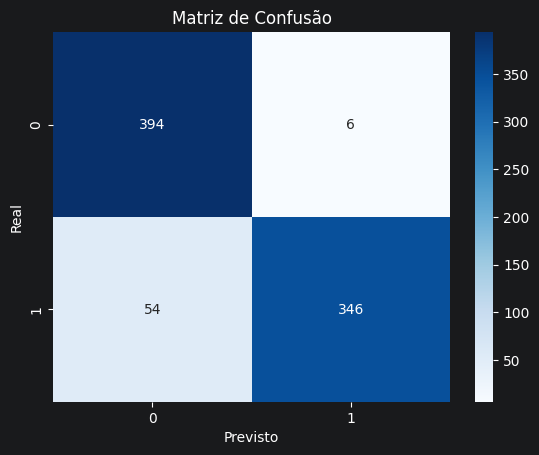

In [19]:
rotulos_reais = []
rotulos_previstos = []

model.eval()

with torch.no_grad():
    for imagens, rotulos in loader_teste:
        imagens = imagens.to(device)
        saidas = model(imagens)
        _, previstos = torch.max(saidas, 1)
        rotulos_reais.extend(rotulos.tolist())
        rotulos_previstos.extend(previstos.cpu().tolist())

print(classification_report(rotulos_reais, rotulos_previstos))

matriz_confusao = confusion_matrix(rotulos_reais, rotulos_previstos)
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

## Salvamento do Modelo Treinado

Após o treinamento e avaliação, os pesos do modelo são salvos para uso futuro em inferência.

Também é armazenado o mapeamento das classes, garantindo consistência entre os rótulos utilizados no treinamento e durante a predição.

Arquivos gerados:

- arquivo .pth contendo os pesos da rede neural
- arquivo .json contendo o mapeamento das classes

In [5]:
PASTA_MODELOS = "../modelos"

os.makedirs(PASTA_MODELOS, exist_ok=True)

# salvar pesos
torch.save(model.state_dict(),f"{PASTA_MODELOS}/synthetic_face_detection.pth")

# salvar class map
with open(f"{PASTA_MODELOS}/mapa_classes.json", "w") as f:
    json.dump(dataset.dataset.class_to_idx, f, indent=4)

print("modelo salvo em /modelos")

NameError: name 'model' is not defined